# Sleep Profiler EEG macro- and micro-architecture Data Analysis

In [1]:
## load dependencies
import pandas as pd
import numpy as np
import mne
import yasa
from matplotlib import pyplot as plt
import seaborn as sns
import os

## Import EEG.edf file(s)

In [2]:
## Establish where EEG files are stored for retrieval
file_path = []

In [3]:
## import EEG.edf file and hypnogram (csv)
raw = mne.io.read_raw_edf('KellyS_Test.edf',
                          infer_types= True, ## tries to automatically understand what channel is which based on name
                           preload=True) 

## preload (default = False) preloads data into memory for faster indexing (requires large amount of memory) and may not be required but is recommended in later method below.
## mne.io.raw documentation recommends preload = True, otherwise edge artifacts appear when slices of the dignal are requested. 

Extracting EDF parameters from /Users/thomasgooding/Desktop/Git_mats/Portfolio/Data_Projects/Rutgers Research/Sleep_Profiler_SOP/KellyS_Test.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6918399  =      0.000 ... 27024.996 secs...


In [4]:
raw = mne.io.read_raw_edf('KellyS_Test.edf',
                          eog = ['EEG2', 'EEG3'],
                          infer_types= True, ## tries to automatically understand what channel is which based on name
                           preload=True) 

Extracting EDF parameters from /Users/thomasgooding/Desktop/Git_mats/Portfolio/Data_Projects/Rutgers Research/Sleep_Profiler_SOP/KellyS_Test.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6918399  =      0.000 ... 27024.996 secs...


In [5]:
print(raw)

<RawEDF | KellyS_Test.edf, 26 x 6918400 (27025.0 s), ~1.34 GB, data loaded>


In [71]:
print(raw.info['sfreq'], 'Hz')

256.0 Hz


In [70]:
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: EEG1, EEG2, EEG3, EEG4, Tilt1, Tilt2, Tilt3, IRED, RED, Snore
 chs: 1 EMG, 2 EOG, 1 EEG, 4 misc, 2 BIO
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2025-02-13 01:01:48 UTC
 nchan: 10
 projs: []
 sfreq: 256.0 Hz
 subject_info: 1 item (dict)
>


In [6]:
raw.info ## this is considered an attribute (vs. a method)

# attributes = static properties of Python objects- things that are pre-computed and stored as part of the object's representation in memory. Attributes are accessed with the . operator and don't require parentheses after the attribute name

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"24 EEG, 2 EOG"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [ ]:
raw.info.keys()
## fields in an info object act like dictionary keys, using square brackets and strings to access the contents of a field

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'dev_head_t', 'ch_names', 'nchan'])

In [ ]:
raw.info['ch_names']
## fields in an info object act like dictionary keys, using square brackets and strings to access the contents of a field. Example

['EEG1',
 'EEG2',
 'EEG3',
 'EEG4',
 'Tilt1',
 'Tilt2',
 'Tilt3',
 'IRED',
 'RED',
 'Snore']

In [77]:
raw.info['chs'][0].keys()

dict_keys(['cal', 'logno', 'scanno', 'range', 'unit_mul', 'ch_name', 'unit', 'coord_frame', 'coil_type', 'kind', 'loc'])

In [81]:
mne.pick_types(raw.info, meg=False, eeg=True)

array([3])

In [82]:
print(mne.pick_types(raw.info, meg=False, eeg=True))

[3]


In [ ]:
events = mne.find_events(raw = raw, stim_channel=['EEG4'])
sfreq = raw.info['sfreq']


In [86]:
events

array([], shape=(0, 3), dtype=int32)

In [7]:
raw.info['chs'] ## a list of channel information dictionaires, one per channel. See MNE notes for more info.

## I made the channel information into a DF, for potential later use.
chs_info_df = pd.DataFrame(raw.info['chs'])

# chs_info_df

raw.info['loc'] can be used to establish channel location information. The first three elements [0:3] always store the nominal channel position. The remaining 9 elements store different information based on the channel type: 
- **EEG**: Elements [3:6] contain reference channel position
- **Eyetrack**: Element [3] contains information about which eye was tracked (-1 for left, 1 for right), and element [4] contains information about the axis of coordinate data (-1 for x-coordinate data, 1 for y-coordinate data).
- **Dipole:** Elements [3:6] contain dipole orientation information.
- **logno:** logical channel number, conventions in the usage of this number may vary.
- **range**: the hardware-oriented part of the calibraiton factor. should only be applied to continuous raw data. Used in product with [cal] to scale data read from disk.
- **events**: can include channels (list of channels) list of int.
- **hpi_meas**: things like sfreq (sample rate), nchan, first_samp, last_samp, hpi_coils (more under this last one.)
  - **Similar attributes might have relevant info I can find from Sleep Profiler's own validation studies or similar publications (e.g., operation manual).**
- **subject_info** dict. This includes first_ last_name, dob, sex, height, weight, handedness...Could potentially 'fit' our data better in future against the same dataset that YASA used...AI/ML. The Rutgers data is the testing dataset and the



**Not relevant but also included:**
- **MEG:** Remaining 9 elements [3:], contain the EX, EY, and EZ normal triplets (columns) of the coil rotation/orientation matrix.


In [8]:
## get channel names, another attribute

# raw.ch_names

In [9]:
## drop channels TC0 to TC15. These are internal to the X8 device and not phyisological signal (may learn otherwise later)
raw.drop_channels([f'TC{i}' for i in range(16)]) # this is considered a Python method ()

## methods are specialized functions attached to an object. Usually, these require additional user input (kwargs) and/or some computation to provide a result. These always have () at the end and additional arguments go inside the ().

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"8 EEG, 2 EOG"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [10]:
## set channel types for mapping
channel_types = {
    'EEG1':'emg', 'EEG2':'eog', 'EEG3':'eog', 'EEG4':'eeg', 'Tilt1': 'misc', 'Tilt2':'misc',
    'Tilt3':'misc', 'IRED':'bio', 'RED':'bio', 'Snore':'misc'}

raw.set_channel_types(channel_types)
## this works even though the output is a dropdown (note the Good channel types) compared to the previous window

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_82054/1898907110.py:6: RuntimeWarning: The unit for channel(s) Snore, Tilt1, Tilt2, Tilt3 has changed from V to NA.
  raw.set_channel_types(channel_types)


Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"1 EMG, 2 EOG, 1 EEG, 4 misc, 2 BIO"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [11]:
print(raw.get_channel_types())

['emg', 'eog', 'eog', 'eeg', 'misc', 'misc', 'misc', 'bio', 'bio', 'misc']


In [12]:
raw.info
## Notes:
## Highpass = 0, lowpass = 128 Hz from a sampling frequency of 256 Hz (lowpass set to 1/2 if H-pass is 0, per documentation).

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"1 EMG, 2 EOG, 1 EEG, 4 misc, 2 BIO"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


## Define Functions

**Important:**
- Sleep Profiler EEG/EOG channels are inverted against the standard y-axis orientation (- deflection is upward, + deflection = downward is standard for EEG). SP has + as upward and - as downward, which may potentially cause issues with waveform characteristics being used to stage sleep and bandpower metrics. 
- The following visual of 'EEG4' (the EEG channel) plots a visual of the impedance testing that occurs every 15 minutes in the SP headband (marked at 0:15:10 in the EEG.edf file.) Identifying these tests were what allowed me to properly identify each channel from the headband in Python/EDFBrowser. 
- Here, these channels and the orientation of the waveform characteristic will be used to determine if the EEG waveform y-axis is inverted against standard convention (important for proper analysis) or is properly oriented, despite looking inverted in Sleep Profiler's own Study Editor Tool. 

10-2-26: TG

In [92]:
## Convert time string to seconds from recording start
def time_to_seconds(time_str):
    """Convert 'H:MM:SS' to total seconds."""
    parts = time_str.split(':')
    return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])

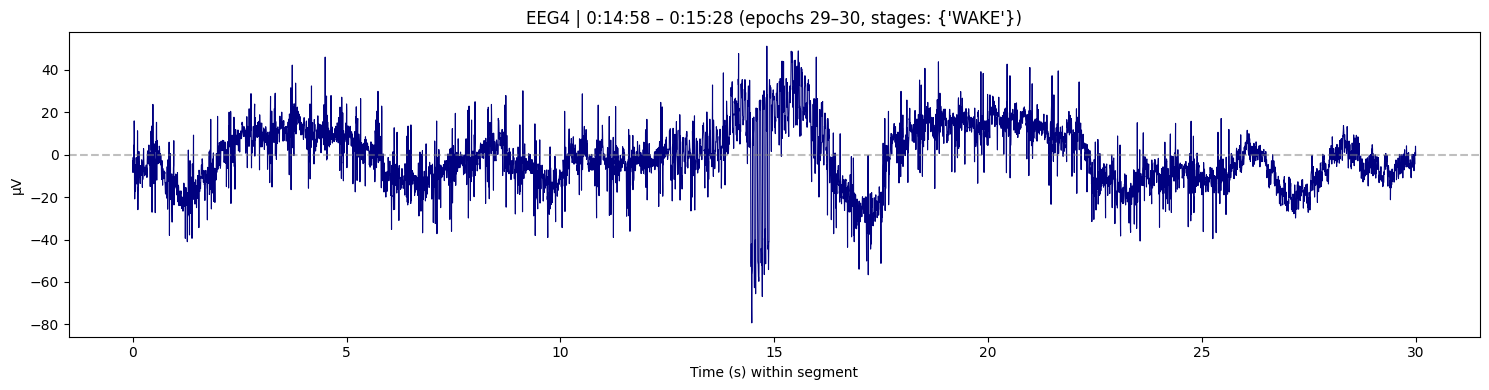

In [100]:
## Define window of time to graph
start_time_str = '0:14:58'
end_time_str   = '0:15:28'

start_sec = time_to_seconds(start_time_str)  ## 898 seconds
end_sec   = time_to_seconds(end_time_str)    ## 928 seconds

## Convert to samples
start_samp = start_sec * sf
end_samp   = end_sec   * sf

## Extract and plot
eeg4 = raw.get_data(picks='EEG4')[0][start_samp:end_samp] * 1e6 * -1
t    = np.arange(len(eeg4)) / sf

# What epoch does this window fall in?
start_epoch = start_sec // 30
end_epoch   = end_sec   // 30
stages      = [hyp.hypno.iloc[e] for e in range(start_epoch, end_epoch + 1)
               if e < len(hyp.hypno)]

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(t, eeg4, color='navy', linewidth=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (s) within segment')
ax.set_ylabel('µV')
ax.set_title(
    f'EEG4 | {start_time_str} – {end_time_str} '
    f'(epochs {start_epoch}–{end_epoch}, stages: {set(stages)})'
)
plt.tight_layout()
plt.show()

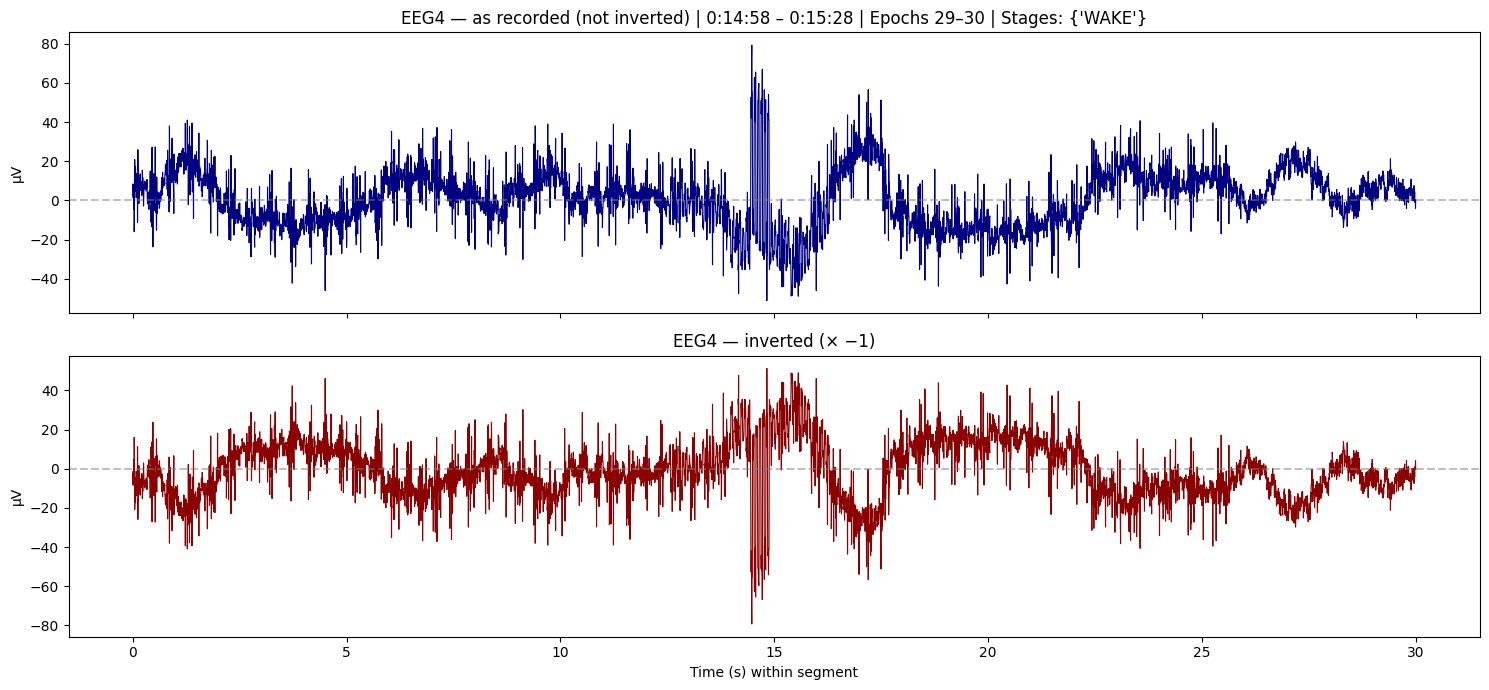

In [ ]:
# Define time window
start_time_str = '0:14:58'
end_time_str   = '0:15:28'

start_sec = time_to_seconds(start_time_str)
end_sec   = time_to_seconds(end_time_str)

## Convert to samples
start_samp = start_sec * sf
end_samp   = end_sec   * sf

# Extract signal — base version (not inverted)
eeg4 = raw.get_data(picks='EEG4')[0][start_samp:end_samp] * 1e6
t    = np.arange(len(eeg4)) / sf

# Epoch/stage annotation
start_epoch = start_sec // 30
end_epoch   = end_sec   // 30
stages      = [hyp.hypno.iloc[e] for e in range(start_epoch, end_epoch + 1)
               if e < len(hyp.hypno)]

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# Top: as recorded
axes[0].plot(t, eeg4, color='navy', linewidth=0.8)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('µV')
axes[0].set_title(
    f'EEG4 — as recorded (not inverted) | '
    f'{start_time_str} – {end_time_str} | '
    f'Epochs {start_epoch}–{end_epoch} | '
    f'Stages: {set(stages)}'
)

# Bottom: inverted
axes[1].plot(t, eeg4 * -1, color='darkred', linewidth=0.8)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('µV')
axes[1].set_title('EEG4 — inverted (× −1)')
axes[1].set_xlabel('Time (s) within segment')

plt.tight_layout()
plt.show()

## Import hypnogram


Column definitions
- Subject # = subject_id
- Epoch # = each 30-sc epoch from the start of data collection period
- Primary autostage is SleepProfiler's initial scoring of each 30-s epoch, 
- Secondary autostage would be the classification if a stage was "light N2" or had partial scoring between two stages, 
- TechEditStage would be the epoch's score if a researcher manually changed that epoch's stage from Sleep Profiler's algorithm
- Stagefinal is the final score for each 30-s epoch (each row = 30s epoch).

In [14]:
## import hypnogram
hypno = pd.read_csv('KellyS_epoch_data.csv')

hypno.head()

,Subject #,Epoch #,Night,StudyDate,ElapsedTime,ElapsedTime(sec),ClockTime,PrimaryAutoStage,SecondaryAutoStage,TechEditStage,Stage final,ChannelStaged,ImpLEOG,ImpREOG,ImpEEG
0,421000303,1,1,13-Feb-25,0:00:31,31,1:02:22,0,0,NaN,0,EEG,4,2,6
1,421000303,2,1,13-Feb-25,0:01:01,61,1:02:52,0,0,NaN,0,EEG,4,2,6
2,421000303,3,1,13-Feb-25,0:01:31,91,1:03:22,0,0,NaN,0,EEG,4,2,6
3,421000303,4,1,13-Feb-25,0:02:01,121,1:03:52,0,0,NaN,0,EEG,4,2,6
4,421000303,5,1,13-Feb-25,0:02:31,151,1:04:22,0,0,NaN,0,EEG,4,2,6


In [15]:
hypno.columns = hypno.columns.str.lower().str.replace(' ', '_')

hypno.columns

Index(['subject_#', 'epoch_#', 'night', 'studydate', 'elapsedtime',
       'elapsedtime(sec)', 'clocktime', 'primaryautostage',
       'secondaryautostage', 'techeditstage', 'stage_final', 'channelstaged',
       'impleog', 'impreog', 'impeeg'],
      dtype='object')

In [16]:
## map hypnogram to 5 stages based on SleepProfiler stage scoring documentation
## Dr. Spaeth and I have agreed on this mapping
stage_map = {
    0 : 'WAKE',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'N2', ## Light N2 (Still N2)
    5: 'REM', 
    6: 'UNS', ## sleep not otherwise specified
    9: 'UNS', ## artifact/ INVALID
    14: 'N2',
    33: 'N3', ## atypical N3, mapped to N3
    55: 'REM' ## REM without atonia, mapped to REM
}

hypno_sorted = hypno.sort_values('epoch_#').copy()
hypno_sorted['yasa_stage'] = hypno_sorted['stage_final'].map(stage_map)

# Check nothing fell through unmapped
print(hypno_sorted["yasa_stage"].isna().sum(), "unmapped epochs")

stage_sequence = hypno_sorted["yasa_stage"].values
hyp = yasa.Hypnogram(stage_sequence, freq="30s")

0 unmapped epochs


In [17]:
hypno.describe()
## count = 899 of 30 second epochs = 449.5 minutes

,subject_#,epoch_#,night,elapsedtime(sec),primaryautostage,secondaryautostage,techeditstage,stage_final,impleog,impreog,impeeg
count,899.0,899.000000,899.0,899.000000,899.000000,899.000000,0.0,899.000000,899.000000,899.000000,899.000000
mean,421000303.0,450.000000,1.0,13501.000000,2.652948,2.598443,NaN,2.652948,1.529477,26.291435,35.028921
std,0.0,259.663243,0.0,7789.897304,1.344675,1.372672,NaN,1.344675,0.760940,75.325483,85.211653
min,421000303.0,1.000000,1.0,31.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
25%,421000303.0,225.500000,1.0,6766.000000,2.000000,2.000000,NaN,2.000000,1.000000,1.000000,1.000000
50%,421000303.0,450.000000,1.0,13501.000000,2.000000,2.000000,NaN,2.000000,1.000000,1.000000,1.000000
75%,421000303.0,674.500000,1.0,20236.000000,3.000000,3.000000,NaN,3.000000,2.000000,2.000000,2.000000
max,421000303.0,899.000000,1.0,26971.000000,5.000000,5.000000,NaN,5.000000,4.000000,252.000000,252.000000


In [18]:
hypno.columns = hypno.columns.str.lower().str.replace(' ', '_')

hypno.columns

Index(['subject_#', 'epoch_#', 'night', 'studydate', 'elapsedtime',
       'elapsedtime(sec)', 'clocktime', 'primaryautostage',
       'secondaryautostage', 'techeditstage', 'stage_final', 'channelstaged',
       'impleog', 'impreog', 'impeeg'],
      dtype='object')

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_82054/1964525906.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stage_labels.values())


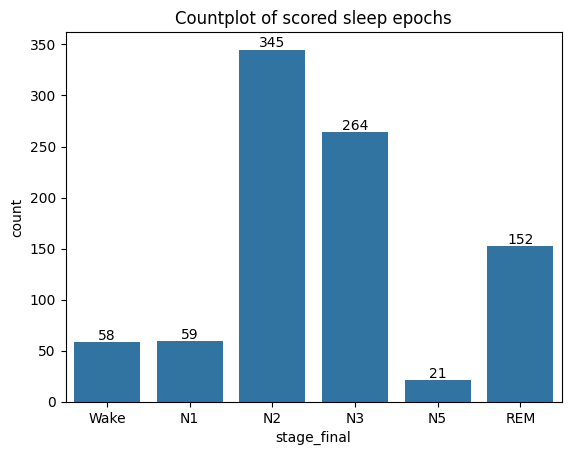

In [19]:
ax = sns.countplot(data= hypno, x='stage_final')
ax.bar_label(ax.containers[0], label_type = 'edge')

## labels based on SleepProfiler documentation
stage_labels = {
    0 : 'Wake',
    1 : 'N1',
    2 : 'N2',
    3 : 'N3', 
    4 : 'N5',
    5 : 'REM'
}

ax.set_xticklabels(stage_labels.values())
ax.set_title('Countplot of scored sleep epochs')
plt.show()

## 899 total count (30s) = 449.5 min, the TIB values from hypnogram.sleep_statistics() below

## MNE Raw methods and attributes for potential use:

This is just a placeholder for potential functions (methods/attributes) I might use for this process. As I'm reading through documentation, I'm just placing these here for future reference.


- raw.crop() can isolate a window of time (seconds) including start/stop as arguments.
- raw.rename_channels()
- raw.drop_channels()
- raw.get_data() for if you want the data and not the corresponding array of times

### Spectrum and EpochsSpectrum classes: frequency-domain data

source: 
https://mne.tools/stable/auto_tutorials/time-freq/10_spectrum_class.html

### MNE Preprocessing documentation

https://mne.tools/stable/api/preprocessing.html

- MNE preprocessing Independent Component Analysis (ICA) available but lengthy documentation

I don't know if this is relevant but flagged it anyways.

## Pre-processing stage: Artifact removal

In [20]:
## map hypnogram stages based on SleepProfiler stage scoring documentation
stage_map = {
    0 : 'WAKE',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'N2', ## Light N2 (Still N2)
    5: 'REM', 
    6: 'UNS', ## sleep not otherwise specified
    9: 'UNS', ## artifact/ INVALID
    14: 'N2',
    33: 'N3', ## atypical N3, mapped to N3
    55: 'REM' ## REM without atonia, mapped to REM
}

hypno_sorted = hypno.sort_values('epoch_#').copy()
hypno_sorted['yasa_stage'] = hypno_sorted['stage_final'].map(stage_map)

# Check nothing fell through unmapped
print(hypno_sorted["yasa_stage"].isna().sum(), "unmapped epochs")

stage_sequence = hypno_sorted["yasa_stage"].values
hyp = yasa.Hypnogram(stage_sequence, freq="30s")

0 unmapped epochs


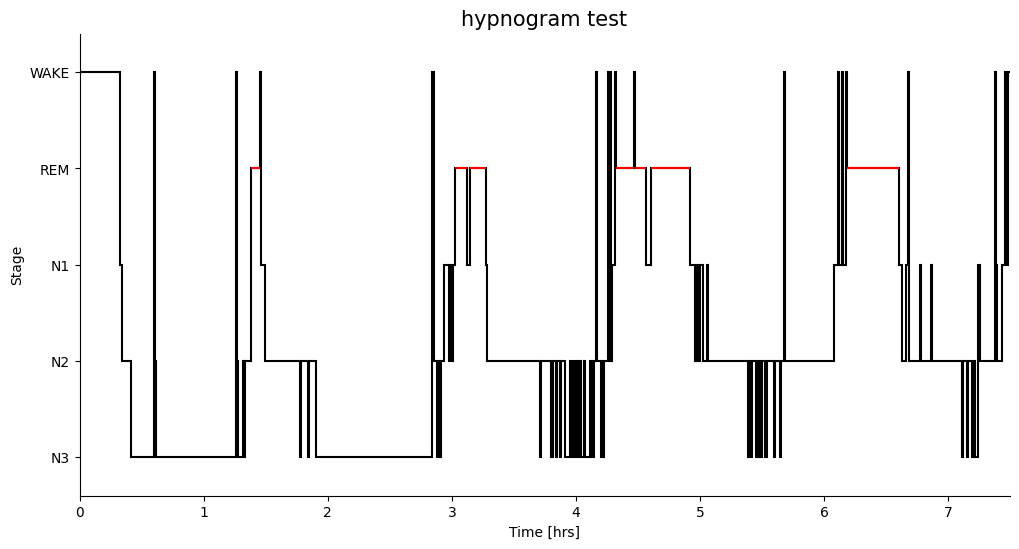

In [21]:
fig, ax = plt.subplots(figsize=(12,6))

ax = hyp.plot_hypnogram()

plt.title('hypnogram test', fontsize=15)
plt.show()

# Get Sleep Descriptive Statistics

In [22]:
hyp.sleep_statistics()

{'TIB': np.float64(449.5),
 'SPT': np.float64(429.5),
 'WASO': np.float64(9.0),
 'TST': np.float64(420.5),
 'SE': np.float64(93.5484),
 'SME': np.float64(97.9045),
 'SFI': np.float64(1.2128),
 'SOL': np.float64(19.5),
 'SOL_5min': np.float64(19.5),
 'Lat_REM': np.float64(83.0),
 'WAKE': np.float64(29.0),
 'N1': np.float64(29.5),
 'N2': np.float64(183.0),
 'N3': np.float64(132.0),
 'REM': np.float64(76.0),
 '%N1': np.float64(7.0155),
 '%N2': np.float64(43.5196),
 '%N3': np.float64(31.3912),
 '%REM': np.float64(18.0737)}

In [23]:
counts, probs = hyp.transition_matrix()
## counts = number of transitions from stage A to B. pre-transition states are the rows and the post-transition states are the columns
display(counts)

## conditional probability transition matrix, i.e., given that current state is A, what is the probability that the next state is B. Stochastic matrix
display(probs.round(3))

To Stage,WAKE,N1,N2,N3,REM
From Stage,,,,,
WAKE,40,6,8,0,3
N1,7,35,14,0,3
N2,5,12,313,35,1
N3,3,1,31,229,0
REM,2,5,0,0,145


To Stage,WAKE,N1,N2,N3,REM
From Stage,,,,,
WAKE,0.702,0.105,0.140,0.000,0.053
N1,0.119,0.593,0.237,0.000,0.051
N2,0.014,0.033,0.855,0.096,0.003
N3,0.011,0.004,0.117,0.867,0.000
REM,0.013,0.033,0.000,0.000,0.954


In [24]:
## the stability of sleep can be calculated by taking the average of the diagonal values of N2, N3, and REM sleep
np.diag(probs.loc['N2':, "N2":]).mean().round(3)

np.float64(0.892)

In [25]:
data_chan = raw.get_data(picks='EEG4')[0]

sf = raw.info['sfreq']

In [26]:
raw.info['sfreq']

256.0

# Fixing here

In [ ]:
## map hypnogram to 5 stages based on SleepProfiler stage scoring documentation
## Dr. Spaeth and I have agreed on this mapping
stage_map = {
    0 : 'WAKE',
    1: 'N1',
    2: 'N2',
    3: 'N3',
    4: 'N2', ## Light N2 (Still N2)
    5: 'REM', 
    6: 'UNS', ## sleep not otherwise specified
    9: 'UNS', ## artifact/ INVALID
    14: 'N2',
    33: 'N3', ## atypical N3, mapped to N3
    55: 'REM' ## REM without atonia, mapped to REM
}

hypno_sorted = hypno.sort_values('epoch_#').copy()
hypno_sorted['yasa_stage'] = hypno_sorted['stage_final'].map(stage_map)

# Check nothing fell through unmapped
print(hypno_sorted["yasa_stage"].isna().sum(), "unmapped epochs")

stage_sequence = hypno_sorted["yasa_stage"].values
hyp = yasa.Hypnogram(stage_sequence, freq="30s")

Make sure this mapping above follows the key for yasa.bandpower()

- When passing an integer array, hypnogram values follow this mapping:
-  -2 = Unscored
- -1 = Artefact / Movement
- 0 = Wake
-  1 = N1 sleep
-  2 = N2 sleep
-  3 = N3 sleep
-  4 = REM sleep


In [27]:
## EEG power in specific frequency bands
## default is that this is in relative power across all channels
yasa.bandpower(raw)

,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Chan,,,,,,,,,
EEG1,0.862323,0.069138,0.024501,0.013201,0.022314,0.008523,8.651418,0.25,True
EEG2,0.814777,0.096311,0.037733,0.024997,0.020792,0.005390,24.223728,0.25,True
EEG3,0.791590,0.104452,0.043975,0.029124,0.024477,0.006382,21.503423,0.25,True
EEG4,0.773219,0.116793,0.046958,0.033028,0.025094,0.004910,43.406059,0.25,True
Tilt1,0.773101,0.226861,0.000022,0.000007,0.000007,0.000002,35.602820,0.25,True
Tilt2,0.643184,0.356770,0.000026,0.000010,0.000009,0.000002,33.123317,0.25,True
Tilt3,0.751290,0.248679,0.000017,0.000006,0.000006,0.000002,27.493463,0.25,True
IRED,0.988882,0.008582,0.000758,0.000286,0.000941,0.000551,0.000009,0.25,True
RED,0.988882,0.008582,0.000758,0.000286,0.000941,0.000551,0.000009,0.25,True


In [28]:
# raw.plot()
## pops up GUI to look at the different channels

In [29]:
## EEG power in specific frequency bands
## here is the absolute power across all channels
yasa.bandpower(raw, relative=False).round(3)

,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Chan,,,,,,,,,
EEG1,7.460,0.598,0.212,0.114,0.193,0.074,8.651,0.25,False
EEG2,19.737,2.333,0.914,0.606,0.504,0.131,24.224,0.25,False
EEG3,17.022,2.246,0.946,0.626,0.526,0.137,21.503,0.25,False
EEG4,33.562,5.070,2.038,1.434,1.089,0.213,43.406,0.25,False
Tilt1,27.525,8.077,0.001,0.000,0.000,0.000,35.603,0.25,False
Tilt2,21.304,11.817,0.001,0.000,0.000,0.000,33.123,0.25,False
Tilt3,20.656,6.837,0.000,0.000,0.000,0.000,27.493,0.25,False
IRED,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.25,False
RED,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.25,False


In [56]:
eeg_channels = ['EEG4']
raw_eeg = raw.copy().pick(eeg_channels)

In [87]:
# yasa.bandpower(raw_eeg, hypno= hyp, include = ['W', 'N1', 'N2', 'N3', 'REM'])

In [60]:
yasa.bandpower(raw_eeg, hypno = hyp)

01-Oct-26 21:01:30 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


,,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Stage,Chan,,,,,,,,,
2,EEG4,0.710564,0.121066,0.068695,0.063850,0.030283,0.005542,38.376501,0.25,True
3,EEG4,0.923541,0.049839,0.014855,0.008527,0.002712,0.000527,303.299516,0.25,True


In [ ]:
## can also pass a hypnogram to calculate the spectral powers separately for each sleep stage. In the example belo, we pass hypnogram object directly and use string stage labels for include. then, save the results in a new variable named 'bandpower'
bandpower = yasa.bandpower(raw, hypno = hyp, include=['N2', 'N3', 'REM'])

bandpower

01-Oct-26 20:58:17 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


,,Delta,Theta,Alpha,Sigma,Beta,Gamma,TotalAbsPow,FreqRes,Relative
Stage,Chan,,,,,,,,,
2,EEG4,0.710564,0.121066,0.068695,0.063850,0.030283,0.005542,38.376501,0.25,True
3,EEG4,0.923541,0.049839,0.014855,0.008527,0.002712,0.000527,303.299516,0.25,True
4,EEG4,0.673135,0.150911,0.046396,0.031476,0.080664,0.017417,14.019210,0.25,True


# Events detection

## Detect Sleep Spindles

In [31]:
sp = yasa.spindles_detect(
    raw.get_data(picks='EEG4')[0] * 1e6,  # µV, single channel
    raw.info['sfreq'],
    hypno=hyp,
    include=("N2", "N3"),   ## N2 and N3 only
    freq_sp=(12, 15), ## spindle frequency band. Can adjust for slow (11-13Hz) vs fast (13-15Hz)
    freq_broad=(1, 30),
    min_distance=500, ## ms between spindles
    # coupling=True,    ## spindle-SO coupling
)
sp_summary = sp.summary(grp_stage=True)  ## aggregate by sleep stage
print(sp_summary)

01-Oct-26 20:46:25 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


       Count   Density  Duration  Amplitude  AmpFiltered        RMS  AbsPower  \
Stage                                                                           
2       1105  6.038251  0.935276  38.269948    24.256031   8.326675  1.830783   
3        165  1.250000  0.830658  46.292419    28.684517  10.417635  1.964526   

       RelPower  Frequency  Oscillations  Symmetry  
Stage                                               
2      0.459964  12.471021     11.415385  0.502539  
3      0.378663  12.383619     10.006061  0.485398  


In [32]:
## summary statistics of all detected sleep spindles (n=1270 rows)
sp.summary()


,Start,Peak,End,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Stage,Channel,IdxChannel
0,1252.199219,1252.402344,1252.812500,0.613281,31.463677,14.734405,6.713212,1.477557,0.261957,12.606399,8.0,0.329114,2,CHAN000,0
1,1259.839844,1260.136719,1260.492188,0.652344,43.039372,25.444722,9.246004,1.818899,0.364423,12.469450,8.0,0.452381,2,CHAN000,0
2,1268.132812,1268.382812,1269.207031,1.074219,31.219279,23.042778,6.887620,1.562799,0.449959,12.472698,13.0,0.231884,2,CHAN000,0
3,1274.785156,1274.996094,1275.597656,0.812500,24.469550,16.380466,5.668907,1.648784,0.525266,12.504452,10.0,0.258373,2,CHAN000,0
4,1277.519531,1278.160156,1278.429688,0.910156,40.158593,23.218884,7.907250,1.752384,0.446534,12.688810,10.0,0.700855,2,CHAN000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1265,26726.738281,26727.050781,26727.425781,0.687500,27.124713,18.829397,5.952717,1.668712,0.547866,13.218066,9.0,0.451977,2,CHAN000,0
1266,26738.371094,26738.847656,26739.406250,1.035156,45.976382,28.786705,9.626578,2.175429,0.671251,13.050696,14.0,0.458647,2,CHAN000,0
1267,26741.902344,26742.300781,26742.796875,0.894531,52.454372,43.522232,11.304587,2.210276,0.646790,12.942289,12.0,0.443478,2,CHAN000,0
1268,26748.722656,26749.187500,26749.683594,0.960938,33.468267,17.886285,7.587170,1.785331,0.517889,12.753991,12.0,0.481781,2,CHAN000,0


In [33]:
## aggregate sleep spindle descriptives, grouped by sleep stage N2 and N3
sp_summary

,Count,Density,Duration,Amplitude,AmpFiltered,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry
Stage,,,,,,,,,,,
2,1105,6.038251,0.935276,38.269948,24.256031,8.326675,1.830783,0.459964,12.471021,11.415385,0.502539
3,165,1.250000,0.830658,46.292419,28.684517,10.417635,1.964526,0.378663,12.383619,10.006061,0.485398


### Plot of average spindle

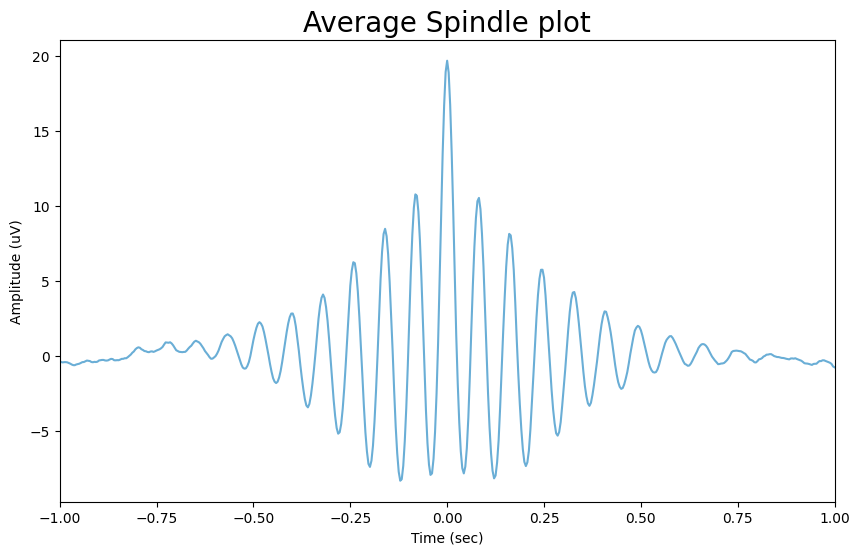

In [34]:
sp.plot_average(ci=None, legend=False, palette='Blues', figsize=(10,6))

plt.title('Average Spindle plot', fontsize=20)
plt.show()

## Detect Slow-waves

In [105]:
# eeg_channels = ['EEG1', 'EEG2', 'EEG3', 'EEG4']
eeg_channels = ['EEG4']
raw_eeg = raw.copy().pick(eeg_channels)

sw = yasa.sw_detect(raw_eeg, hypno= hyp, include=['N2', 'N3'])

sw.summary()

02-Oct-26 15:59:09 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,Stage,Channel,IdxChannel
0,1719.386719,1719.691406,1719.953125,1720.167969,1720.421875,1.0352,-57.968922,39.683884,97.652806,221.493194,0.965997,3,EEG4,0
1,1871.105469,1871.390625,1871.707031,1872.003906,1872.359375,1.2539,-50.867305,41.846577,92.713882,160.765803,0.797512,3,EEG4,0
2,1927.859375,1928.078125,1928.292969,1928.546875,1929.238281,1.3789,-52.036277,57.114201,109.150478,242.205218,0.725216,3,EEG4,0
3,1947.660156,1947.953125,1948.281250,1948.953125,1949.222656,1.5625,-71.996406,75.190161,147.186567,219.417620,0.640000,3,EEG4,0
4,1949.222656,1949.500000,1949.843750,1950.136719,1950.421875,1.1992,-68.926498,49.200598,118.127095,200.513448,0.833889,3,EEG4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,25653.121094,25653.402344,25653.636719,25653.835938,25654.070312,0.9492,-86.580396,65.346880,151.927275,369.409688,1.053519,2,EEG4,0
652,25981.136719,25981.402344,25981.734375,25981.921875,25982.496094,1.3594,-64.283615,14.698960,78.982575,193.607121,0.735619,3,EEG4,0
653,26117.996094,26118.277344,26118.511719,26118.750000,26119.437500,1.4414,-79.066852,70.794921,149.861773,337.351902,0.693770,2,EEG4,0
654,26119.437500,26119.718750,26119.988281,26120.148438,26120.332031,0.8945,-86.677698,34.679142,121.356840,321.586820,1.117943,2,EEG4,0


In [36]:
sw_summary = sw.summary(grp_stage = True)

sw_summary.round(3)

,Count,Density,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency
Stage,,,,,,,,
2,41,0.224,1.354,-57.943,48.456,106.400,199.826,0.784
3,615,4.659,1.259,-57.600,48.814,106.414,203.077,0.835


In [37]:
sw_df = pd.DataFrame(sw.summary())

sw_df.head()

,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,Stage,Channel,IdxChannel
0,1719.386719,1719.691406,1719.953125,1720.167969,1720.421875,1.0352,-57.968922,39.683884,97.652806,221.493194,0.965997,3,EEG4,0
1,1871.105469,1871.390625,1871.707031,1872.003906,1872.359375,1.2539,-50.867305,41.846577,92.713882,160.765803,0.797512,3,EEG4,0
2,1927.859375,1928.078125,1928.292969,1928.546875,1929.238281,1.3789,-52.036277,57.114201,109.150478,242.205218,0.725216,3,EEG4,0
3,1947.660156,1947.953125,1948.281250,1948.953125,1949.222656,1.5625,-71.996406,75.190161,147.186567,219.417620,0.640000,3,EEG4,0
4,1949.222656,1949.500000,1949.843750,1950.136719,1950.421875,1.1992,-68.926498,49.200598,118.127095,200.513448,0.833889,3,EEG4,0


### Average Slow-wave plot

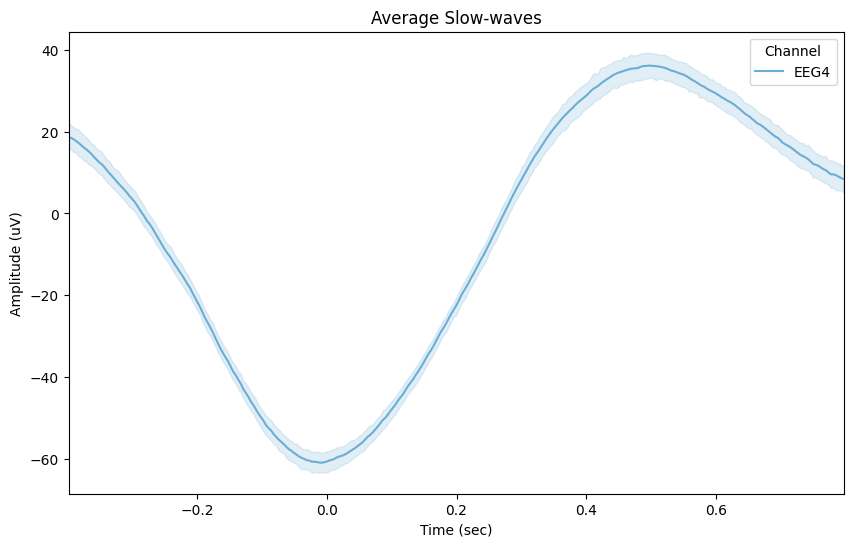

In [38]:
sw.plot_average(ci=99, legend=True, palette='Blues',figsize=(10,6))
plt.title('Average Slow-waves')

plt.show()


In [110]:
# Step 1: Diagnose the mismatch
recording_duration_sec = raw.n_times / raw.info['sfreq']
recording_epochs = recording_duration_sec / 30

print(f"Recording duration:     {recording_duration_sec:.1f} seconds")
print(f"Expected epochs:        {recording_epochs:.1f}")
print(f"Hypnogram epoch count:  {len(hyp.hypno)}")

Recording duration:     27025.0 seconds
Expected epochs:        900.8
Hypnogram epoch count:  899


In [111]:
# Trim raw to match hypnogram length exactly
hypno_duration_sec = len(hyp.hypno) * 30  # 899 × 30 = 26970 seconds

raw_eeg = raw.copy().crop(tmin=0, tmax=hypno_duration_sec).pick(['EEG4'])

# Confirm lengths now align
print(f"Raw duration after crop: {raw_eeg.n_times / raw_eeg.info['sfreq']:.1f}s")
print(f"Hypnogram covers:        {hypno_duration_sec}s")

# Run slow wave detection
sw = yasa.sw_detect(raw_eeg, hypno=hyp, include=['N2', 'N3'])

sw_df = sw.summary()
print(sw_df.head())
print(sw_df[['ValNegPeak', 'PTP']].describe())

02-Oct-26 16:04:02 | WARNING | Hypnogram is SHORTER than data by 0.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


Raw duration after crop: 26970.0s
Hypnogram covers:        26970s


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


         Start      NegPeak  MidCrossing      PosPeak          End  Duration  \
0  1719.386719  1719.691406  1719.953125  1720.167969  1720.421875    1.0352   
1  1871.105469  1871.390625  1871.707031  1872.003906  1872.359375    1.2539   
2  1927.859375  1928.078125  1928.292969  1928.546875  1929.238281    1.3789   
3  1947.660156  1947.953125  1948.281250  1948.953125  1949.222656    1.5625   
4  1949.222656  1949.500000  1949.843750  1950.136719  1950.421875    1.1992   

   ValNegPeak  ValPosPeak         PTP       Slope  Frequency  Stage Channel  \
0  -57.968922   39.683884   97.652806  221.493194   0.965997      3    EEG4   
1  -50.867305   41.846577   92.713882  160.765803   0.797512      3    EEG4   
2  -52.036277   57.114201  109.150478  242.205218   0.725216      3    EEG4   
3  -71.996406   75.190161  147.186567  219.417620   0.640000      3    EEG4   
4  -68.926498   49.200598  118.127095  200.513448   0.833889      3    EEG4   

   IdxChannel  
0           0  
1           

In [113]:
sw.summary()

,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,Stage,Channel,IdxChannel
0,1719.386719,1719.691406,1719.953125,1720.167969,1720.421875,1.0352,-57.968922,39.683884,97.652806,221.493194,0.965997,3,EEG4,0
1,1871.105469,1871.390625,1871.707031,1872.003906,1872.359375,1.2539,-50.867305,41.846577,92.713882,160.765803,0.797512,3,EEG4,0
2,1927.859375,1928.078125,1928.292969,1928.546875,1929.238281,1.3789,-52.036277,57.114201,109.150478,242.205218,0.725216,3,EEG4,0
3,1947.660156,1947.953125,1948.281250,1948.953125,1949.222656,1.5625,-71.996406,75.190161,147.186567,219.417620,0.640000,3,EEG4,0
4,1949.222656,1949.500000,1949.843750,1950.136719,1950.421875,1.1992,-68.926498,49.200598,118.127095,200.513448,0.833889,3,EEG4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,25653.121094,25653.402344,25653.636719,25653.835938,25654.070312,0.9492,-86.580396,65.346880,151.927275,369.409688,1.053519,2,EEG4,0
652,25981.136719,25981.402344,25981.734375,25981.921875,25982.496094,1.3594,-64.283615,14.698960,78.982575,193.607121,0.735619,3,EEG4,0
653,26117.996094,26118.277344,26118.511719,26118.750000,26119.437500,1.4414,-79.066852,70.794921,149.861773,337.351902,0.693770,2,EEG4,0
654,26119.437500,26119.718750,26119.988281,26120.148438,26120.332031,0.8945,-86.677698,34.679142,121.356840,321.586820,1.117943,2,EEG4,0


In [114]:
sw.summary().describe().round(3)

,Start,NegPeak,MidCrossing,PosPeak,End,Duration,ValNegPeak,ValPosPeak,PTP,Slope,Frequency,Stage,IdxChannel
count,656.000,656.000,656.000,656.000,656.000,656.000,656.000,656.000,656.000,656.000,656.000,656.000,656.0
mean,6921.169,6921.511,6921.828,6922.102,6922.434,1.265,-57.621,48.792,106.413,202.874,0.831,2.938,0.0
std,4038.229,4038.242,4038.257,4038.262,4038.285,0.285,14.614,20.529,28.040,71.629,0.189,0.242,0.0
min,1719.387,1719.691,1719.953,1720.168,1720.422,0.672,-148.485,10.130,75.121,43.548,0.456,2.000,0.0
25%,3584.127,3584.412,3584.688,3584.905,3585.274,1.035,-63.379,34.397,86.376,163.565,0.686,3.000,0.0
50%,7582.578,7582.883,7583.188,7583.453,7583.861,1.250,-53.645,44.736,98.789,200.340,0.800,3.000,0.0
75%,9089.938,9090.263,9090.885,9091.310,9091.610,1.457,-47.519,58.539,117.547,238.003,0.966,3.000,0.0
max,26140.578,26140.828,26141.086,26141.352,26141.871,2.195,-40.016,137.704,230.333,559.001,1.488,3.000,0.0


In [ ]:
# Get a sample of low-amplitude events detected with widened thresholds
sw_df_wide = sw.summary()
low_amp_events = sw_df_wide[
    (sw_df_wide['ValNegPeak'] > -40) &   # events below original threshold
    (sw_df_wide['PTP'] < 75)
].head(5)

# Plot each one to confirm they look like genuine slow waves
for _, event in low_amp_events.iterrows():
    start_str_sec = event['Start'] - 2   # 2 seconds before event
    end_str_sec   = event['End'] + 2     # 2 seconds after event
    
    nav.plot_raw_segment(
        start_str_sec,
        end_str_sec,
        channels=['EEG4'],
        scale_uv=100
    )

##### test code-- suss this out

# Automatic Sleep Staging

In [39]:
import yasa
from sklearn.metrics import cohen_kappa_score
import pandas as pd

#  "ground-truth" hypnogram (built earlier from primaryautostage / stage_final)
# 'hyp' should already exist as a yasa.Hypnogram object from your earlier mapping step
ground_truth_int = hyp.as_int().to_numpy()

results = []

# for ch in ["EEG1", "EEG2", "EEG3", "EEG4"]:
for ch in ["EEG4"]:
    print(f"Running SleepStaging on {ch}...")
    
    sls = yasa.SleepStaging(raw, eeg_name=ch)
    hypno_pred = sls.predict()  # yasa.Hypnogram object
    
    pred_int = hypno_pred.as_int().to_numpy()
    
    # Align lengths in case of any epoch-count mismatch
    n = min(len(ground_truth_int), len(pred_int))
    
    kappa = cohen_kappa_score(ground_truth_int[:n], pred_int[:n])
    pct_agree = (ground_truth_int[:n] == pred_int[:n]).mean() * 100
    
    results.append({
        "channel": ch,
        "kappa": kappa,
        "pct_agreement": pct_agree,
    })

comparison_df = pd.DataFrame(results).sort_values("kappa", ascending=False)
print(comparison_df)

Running SleepStaging on EEG4...
  channel     kappa  pct_agreement
0    EEG4  0.665642      76.195773


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


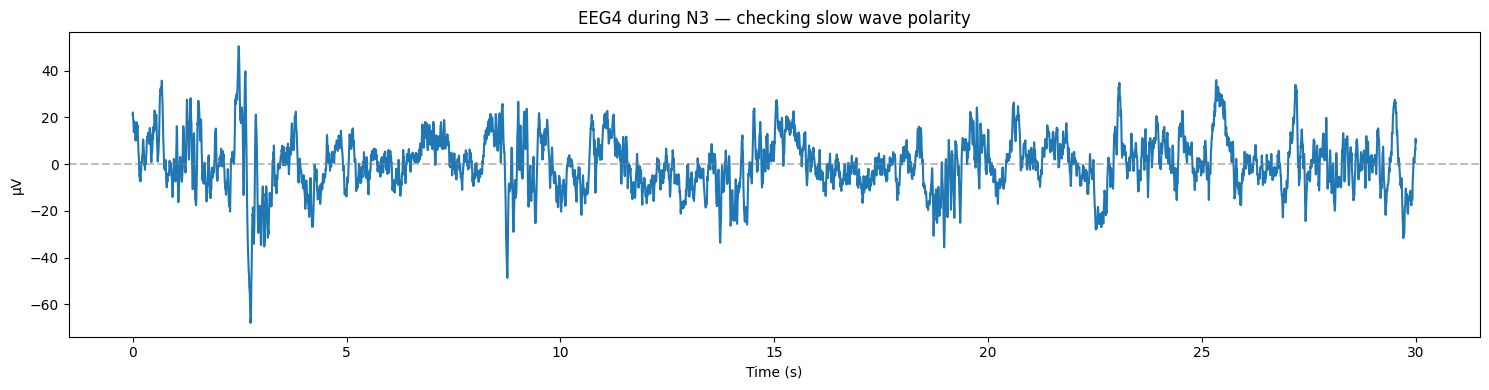

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Plot a 30-second window of EEG4 that contains a clear slow wave
# (pick a confirmed N3 epoch from your hypnogram)
sf = int(raw.info['sfreq'])

# Find first N3 epoch
hypno_int = hyp.as_int().to_numpy()
n3_epochs = np.where(hypno_int == 3)[0]
first_n3 = n3_epochs[0]
start = first_n3 * 30 * sf
end = start + 30 * sf

eeg4 = raw.get_data(picks='EEG4')[0][start:end] * 1e6
t = np.arange(len(eeg4)) / sf

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(t, eeg4)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('µV')
ax.set_title('EEG4 during N3 — checking slow wave polarity')
plt.tight_layout()
plt.show()

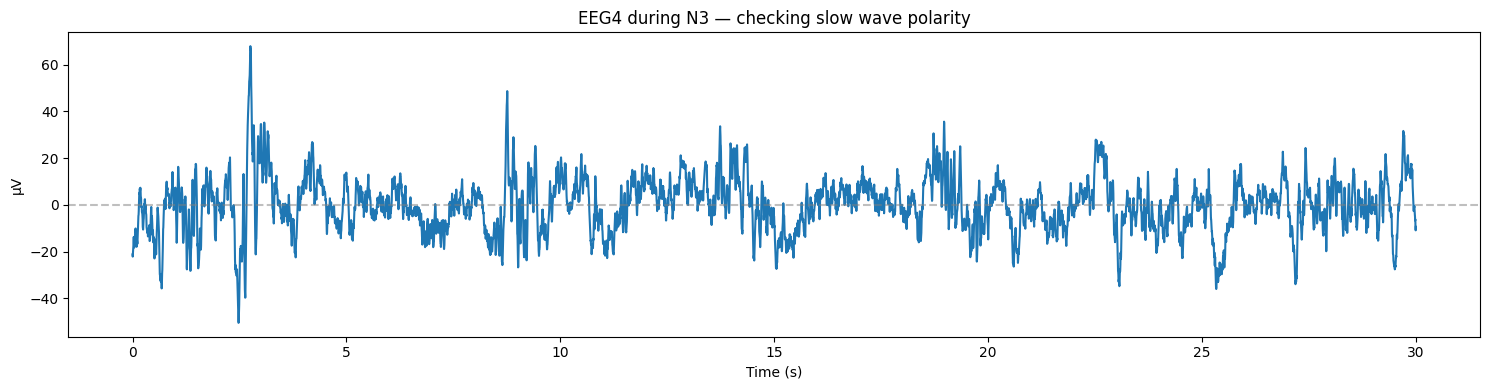

In [41]:
### Invert the EEG plot

sf = int(raw.info['sfreq'])

## Find first N3 epoch
hypno_int = hyp.as_int().to_numpy()
n3_epochs = np.where(hypno_int == 3)[0]
first_n3 = n3_epochs[0]
start = first_n3 * 30 * sf
end = start + 30 * sf

eeg4 = raw.get_data(picks='EEG4')[0][start:end] * 1e6 * -1
t = np.arange(len(eeg4)) / sf

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(t, eeg4)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('µV')
ax.set_title('EEG4 during N3 — checking slow wave polarity')
plt.tight_layout()
plt.show()

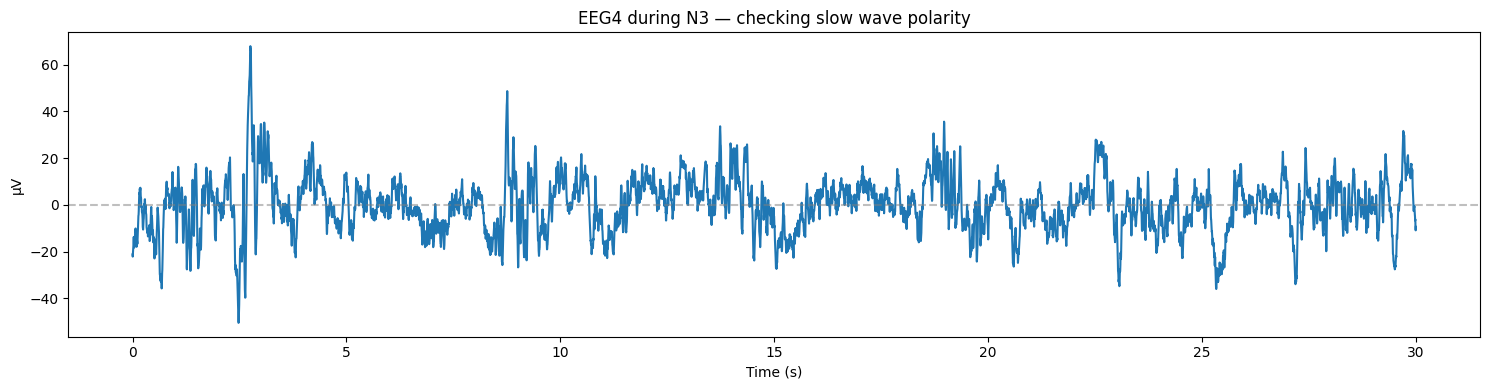

In [89]:
### Invert the EEG plot

sf = int(raw.info['sfreq'])

## Find first N3 epoch
hypno_int = hyp.as_int().to_numpy()
n3_epochs = np.where(hypno_int == 3)[0]
first_n3 = n3_epochs[0]
start = first_n3 * 30 * sf
end = start + 30 * sf

eeg4 = raw.get_data(picks='EEG4')[0][start:end] * 1e6 * -1
t = np.arange(len(eeg4)) / sf

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(t, eeg4)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('µV')
ax.set_title('EEG4 during N3 — checking slow wave polarity')


plt.tight_layout()
plt.show()

In [42]:
sls_eeg4 = yasa.SleepStaging(raw, eeg_name="EEG4")
pred_eeg4 = sls_eeg4.predict()
print(pred_eeg4.hypno.value_counts())

YASA
N2      380
REM     245
N3      197
WAKE     60
N1       18
ART       0
UNS       0
Name: count, dtype: int64


/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [43]:
sls_eeg4 = yasa.SleepStaging(raw, eeg_name="EEG4")
pred_eeg4 = sls_eeg4.predict()
pred_eeg4.proba.round(2)

/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,WAKE,N1,N2,N3,REM
Epoch,,,,,
0,1.00,0.00,0.00,0.0,0.00
1,1.00,0.00,0.00,0.0,0.00
2,1.00,0.00,0.00,0.0,0.00
3,1.00,0.00,0.00,0.0,0.00
4,1.00,0.00,0.00,0.0,0.00
...,...,...,...,...,...
895,0.27,0.14,0.02,0.0,0.57
896,0.87,0.02,0.01,0.0,0.10
897,0.88,0.06,0.00,0.0,0.06


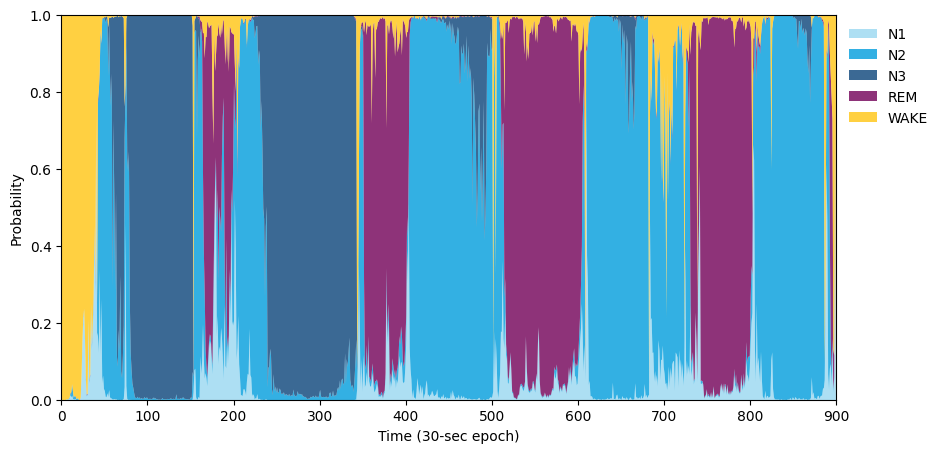

In [44]:
sls_eeg4.plot_predict_proba()

plt.show()

# Spectral Analysis

## Computer Power Spectral Density

Effective window size : 8.000 (s)
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_82054/3175881629.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=50).plot(picks='data', exclude='bads', amplitude=False)
/opt/anaconda3/envs/SleepEEgPy/lib/python3.11/site-packages/mne/viz/utils.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


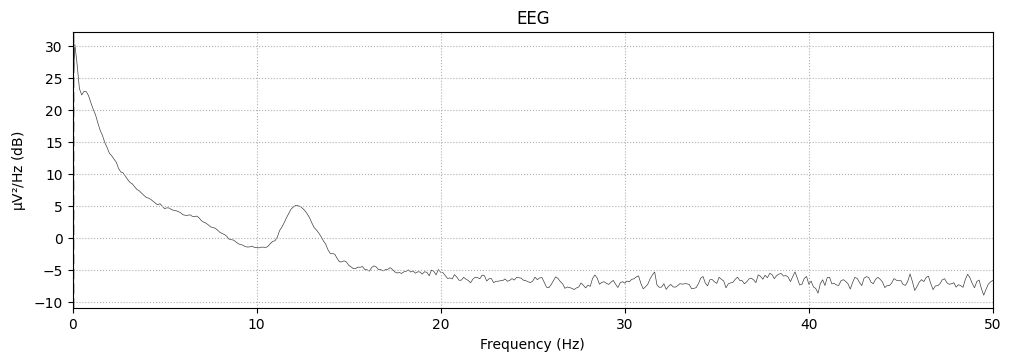

In [46]:
raw.compute_psd(fmax=50).plot(picks='data', exclude='bads', amplitude=False)

## Spectrogram

01-Oct-26 20:46:31 | WARNING | Hypnogram is SHORTER than data by 55.00 seconds. Padding hypnogram with Unscored (UNS) to match data.size.


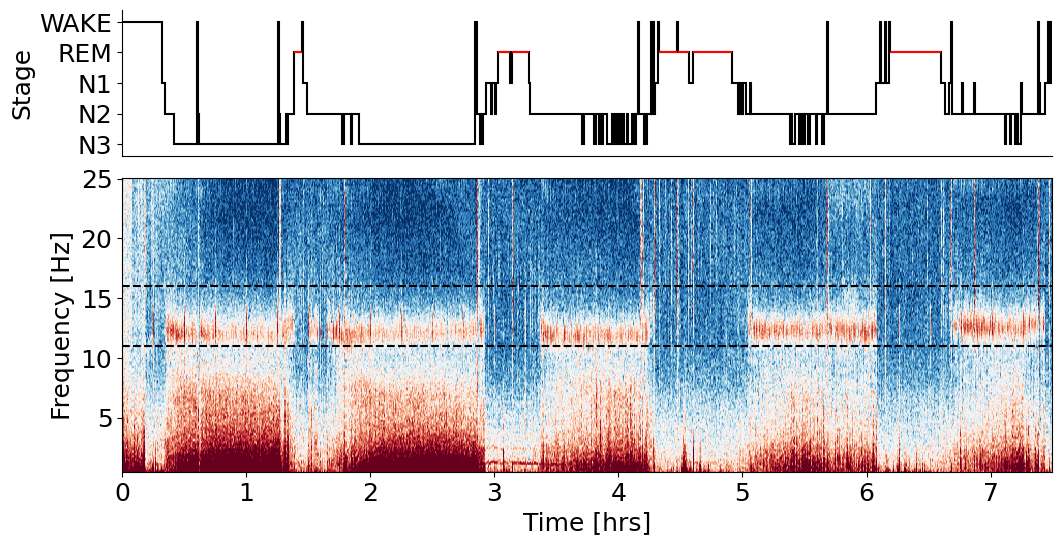

In [45]:
## change these settings prior to plotting spectrogram, as needed
data_chan = raw.get_data(picks='EEG4')[0]
sf = raw.info['sfreq']

yasa.plot_spectrogram(data_chan, sf, hyp)

## Highlight a specific frequency range (in this case, sigma band 11 to 16 Hz)
plt.axhline(y=11, xmin=0, xmax=1, ls='--', color='black')
plt.axhline(y=16, xmin=0, xmax=1, ls='--', color='black')

plt.show()

### Spectrum and EpochsSpectrum classes: frequency-domain data

source: 
https://mne.tools/stable/auto_tutorials/time-freq/10_spectrum_class.html

In [51]:
## import EEG.edf file and hypnogram (csv)
raw = mne.io.read_raw_edf('KellyS_Test.edf',
                          infer_types= True, ## tries to automatically understand what channel is which based on name
                           preload=True) 

## preload (default = False) preloads data into memory for faster indexing (requires large amount of memory) and may not be required but is recommended in later method below.
## mne.io.raw documentation recommends preload = True, otherwise edge artifacts appear when slices of the dignal are requested. 

Extracting EDF parameters from /Users/thomasgooding/Desktop/Git_mats/Portfolio/Data_Projects/Rutgers Research/Sleep_Profiler_SOP/KellyS_Test.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6918399  =      0.000 ... 27024.996 secs...


In [53]:
## drop channels TC0 to TC15. These are internal to the X8 device and not phyisological signal (may learn otherwise later)
raw.drop_channels([f'TC{i}' for i in range(16)]) 

Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,10 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [55]:
## set channel types for mapping
channel_types = {
    'EEG1':'emg', 'EEG2':'eog', 'EEG3':'eog', 'EEG4':'eeg', 'Tilt1': 'misc', 'Tilt2':'misc',
    'Tilt3':'misc', 'IRED':'bio', 'RED':'bio', 'Snore':'misc'}

raw.set_channel_types(channel_types)
## this works even though the output is a dropdown (note the Good channel types) compared to the previous window

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_82054/1898907110.py:6: RuntimeWarning: The unit for channel(s) Snore, Tilt1, Tilt2, Tilt3 has changed from V to NA.
  raw.set_channel_types(channel_types)


Measurement date,"February 13, 2025 01:01:48 GMT"
Experimenter,Unknown
Participant,
Digitized points,Not available
Good channels,"1 EMG, 2 EOG, 1 EEG, 4 misc, 2 BIO"
Bad channels,None
EOG channels,"EEG2, EEG3"
ECG channels,Not available
Sampling frequency,256.00 Hz
Highpass,0.00 Hz
Lowpass,128.00 Hz


In [54]:
raw.compute_psd()

Effective window size : 8.000 (s)


Data type,Power Spectrum
Units,eeg: V²/Hz
Data source,Raw
Dims,"channel, freq"
Estimation method,welch
Number of channels,10
Number of frequency bins,1025
Frequency range,0.00 – 128.00 Hz


In [50]:
raw.compute_psd()

Effective window size : 8.000 (s)


Data type,Power Spectrum
Units,eeg: V²/Hz
Data source,Raw
Dims,"channel, freq"
Estimation method,welch
Number of channels,1
Number of frequency bins,1025
Frequency range,0.00 – 128.00 Hz


# Stop